In [1]:
from dataclasses import dataclass

from CADETProcess.parameter_space import ParameterSpace, RangedParameter


@dataclass
class Column:
    length: float = 0.5
    diameter: float = 0.05


column = Column()

space = ParameterSpace()
space.add_evaluation_object(column)
space.add_parameter(
    RangedParameter("length", float, lb=0.1, ub=1.0), path="length"
)
space.add_parameter(
    RangedParameter("diameter", float, lb=0.01, ub=0.2), path="diameter"
)
space

ParameterSpace(n_variables=2, n_parameters=2, evaluation_objects=1)

In [2]:
space.set_values({"length": 0.75, "diameter": 0.04})
column

Column(length=0.75, diameter=0.04)

In [3]:
space.get_value("length")

0.75

In [4]:
length, diameter = space.independent_parameters
space.add_dependency(diameter, [length], transform=lambda le: le / 10)

space.set_values({"length": 0.6})
column

Column(length=0.6, diameter=0.06)

In [5]:
space.resolve({"length": 0.6})

{'length': 0.6, 'diameter': 0.06}

In [6]:
from CADETProcess.parameter_space import LinearConstraint

flow = ParameterSpace()
flow.add_evaluation_object(Column())
q_load = RangedParameter("q_load", float, lb=0.0, ub=10.0)
q_elute = RangedParameter("q_elute", float, lb=0.0, ub=10.0)
flow.add_parameter(q_load, path="length")
flow.add_parameter(q_elute, path="diameter")

# q_load must not exceed q_elute
flow.add_linear_constraint(LinearConstraint([q_load, q_elute], lhs=[1, -1], b=0))

In [7]:
flow.A, flow.b

(array([[ 1., -1.]]), array([0.]))

In [8]:
flow.evaluate_linear_constraints([5, 3])

array([2.])

In [9]:
from CADETProcess.parameter_space import HopsySampler

wide = ParameterSpace()
wide.add_evaluation_object(Column())
wide.add_parameter(RangedParameter("length", float, lb=0.1, ub=1.0), path="length")
wide.add_parameter(
    RangedParameter("diameter", float, lb=1e-8, ub=1e-4, normalization="log"),
    path="diameter",
)

HopsySampler(pool_size=2000).sample(wide, 5, seed=0)

[{'length': 0.7361705890010992, 'diameter': 5.35843930503049e-06},
 {'length': 0.3908478469790896, 'diameter': 2.9476133878181334e-06},
 {'length': 0.7993459500031496, 'diameter': 1.5497373648095247e-07},
 {'length': 0.43569244767827076, 'diameter': 4.586811178136241e-06},
 {'length': 0.8565068038668763, 'diameter': 8.96022822142557e-07}]

In [10]:
flow.sample(3, seed=42)

[{'q_load': 3.8831707228760255, 'q_elute': 7.827683091188557},
 {'q_load': 2.365878890641694, 'q_elute': 3.0868574064264904},
 {'q_load': 1.4453330847791093, 'q_elute': 9.748866762397784}]

In [11]:
from CADETProcess.parameter_space import HopsySampler, LatinHypercubeSampler

box = ParameterSpace()
box.add_evaluation_object(Column())
box.add_parameter(RangedParameter("x_0", float, lb=0.0, ub=1.0), path="length")
box.add_parameter(RangedParameter("x_1", float, lb=0.0, ub=1.0), path="diameter")

uniform = HopsySampler(pool_size=2000).sample(box, 64, seed=0)
lhs = LatinHypercubeSampler().sample(box, 64, seed=0)

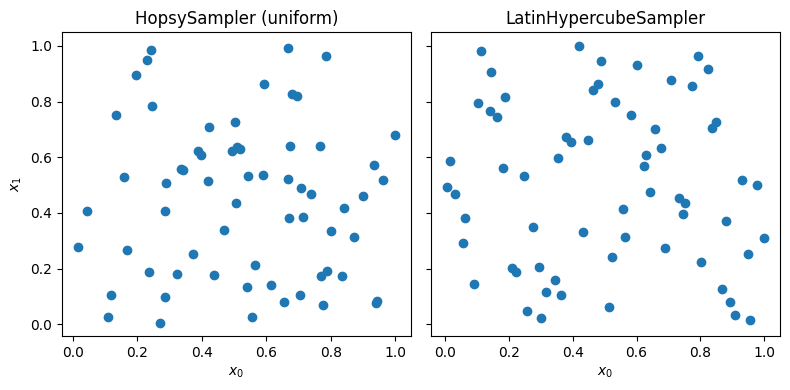

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
for ax, samples, title in [
    (axes[0], uniform, "HopsySampler (uniform)"),
    (axes[1], lhs, "LatinHypercubeSampler"),
]:
    ax.scatter([s["x_0"] for s in samples], [s["x_1"] for s in samples])
    ax.set_title(title)
    ax.set_xlabel(r"$x_0$")
axes[0].set_ylabel(r"$x_1$")
fig.tight_layout()

In [13]:
from CADETProcess.parameter_space import ChoiceParameter

mixed = ParameterSpace()
mixed.add_evaluation_object(Column())
mixed.add_parameter(RangedParameter("n_plates", int, lb=10, ub=100), path="length")
mixed.add_parameter(ChoiceParameter("resin", ["A", "B"]))

samples = LatinHypercubeSampler().sample(mixed, 10, seed=0)
samples[:3]

[{'n_plates': 49, 'resin': 'A'},
 {'n_plates': 64, 'resin': 'A'},
 {'n_plates': 75, 'resin': 'B'}]

In [14]:
[s["resin"] for s in samples].count("A")

5

In [15]:
from CADETProcess.parameter_space import chebyshev_center

chebyshev_center(flow)

{'q_load': 2.928932188134525, 'q_elute': 7.0710678118654755}

In [16]:
from CADETProcess.optimization import OptimizationProblem

problem = OptimizationProblem("sampling_demo", use_diskcache=False)
problem.add_variable("x_0", lb=0, ub=8)
problem.add_variable("x_1", lb=0, ub=1)

problem.create_initial_values(8, seed=1, sampler=LatinHypercubeSampler())

[INFO 08-12 16:21:28] ax.storage.sqa_store.with_db_settings_base: Ax SQL storage initialized with SQLAlchemy 2.0.52


array([[7.48817838, 0.88119204],
       [6.85584039, 0.38141882],
       [2.68816855, 0.32208419],
       [0.17229741, 0.57385011],
       [4.45040631, 0.12155511],
       [5.24648689, 0.80773209],
       [1.67026828, 0.65144641],
       [3.69680517, 0.19331276]])